# Session 4

In [1]:
import pandas as pd
import numpy as np
import sklearn
import graphviz
import scipy
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from tqdm.notebook import tqdm

## Herzkrankheit Datensatz

In [2]:
heart_data = pd.read_csv('..\\Data\\Raw\\heart.csv')
heart_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
# Trainings-, Validierungs-, und Testdaten aufteilen
train_data, test_data = train_test_split(heart_data, test_size=0.4, random_state=0)
val_data, test_data = train_test_split(test_data, test_size=0.5, random_state=0)

# Input und Output Variablen trennen
X_train = train_data.drop("target", axis=1)
y_train = train_data["target"]
X_val = val_data.drop("target", axis=1)
y_val = val_data["target"]
X_test = test_data.drop("target", axis=1)
y_test = test_data["target"]

Relevanteste Hyperparameter:
- criterion
- max_depth
- min_samples_leaf
- min_impurity_decrease

Mehr Details in der [Dokumentation](https://scikit-learn.org/1.5/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [4]:
tree_model = DecisionTreeClassifier(criterion="entropy")
tree_model.fit(X_train, y_train)
print("Train Accuracy:", tree_model.score(X_train, y_train))
print("Validation Accuracy:", round(tree_model.score(X_val, y_val),2))
print("Test Accuracy:", round(tree_model.score(X_test, y_test),2))

Train Accuracy: 1.0
Validation Accuracy: 0.79
Test Accuracy: 0.72


### Pre-Pruning

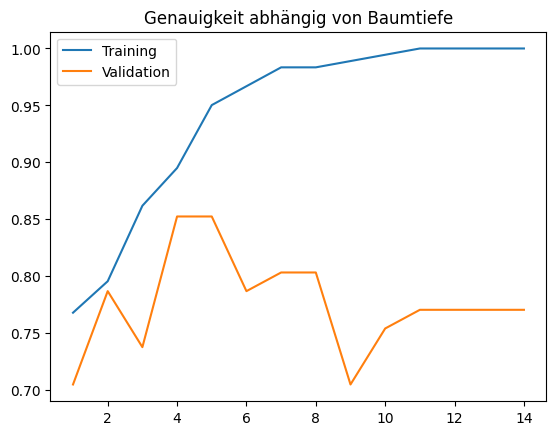

In [10]:
training_results = {}
validation_results = {}

for n in range(1,15):
    tree_model = DecisionTreeClassifier(criterion="entropy", max_depth=n, random_state=0)
    tree_model.fit(X_train, y_train)
    training_results[n] = tree_model.score(X_train, y_train)
    validation_results[n] = (tree_model.predict(X_val) == y_val).mean()

# Ergebnisse des Trainings visuell darstellen
x, y = zip(*training_results.items())
plt.plot(x, y, label="Training")
x, y = zip(*validation_results.items())
plt.plot(x, y, label="Validation")

plt.title("Genauigkeit abhängig von Baumtiefe")
plt.legend()
plt.show()

### Post Pruning

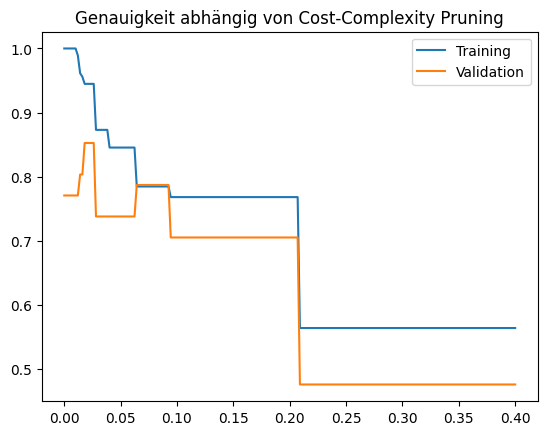

In [11]:
training_results = {}
validation_results = {}

for alpha in np.linspace(0,0.4,200):
    tree_model = DecisionTreeClassifier(criterion="entropy", ccp_alpha=alpha, random_state=0)
    tree_model.fit(X_train, y_train)
    training_results[alpha] = tree_model.score(X_train, y_train)
    validation_results[alpha] = (tree_model.predict(X_val) == y_val).mean()

# Ergebnisse des Trainings visuell darstellen
x, y = zip(*training_results.items())
plt.plot(x, y, label="Training")
x, y = zip(*validation_results.items())
plt.plot(x, y, label="Validation")

plt.title("Genauigkeit abhängig von Cost-Complexity Pruning")
plt.legend()
plt.show()

### Baum Visualisierung

In [13]:
tree_model = DecisionTreeClassifier(criterion="entropy")
tree_model.fit(X_train, y_train)

dot_data = sklearn.tree.export_graphviz(tree_model, out_file=None, 
                              feature_names=X_train.columns,  
                              class_names=["Negative", "Positive"],  
                              filled=True, rounded=True,  
                              special_characters=True)
graph_full = graphviz.Source(dot_data) 
graph_full

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [14]:
# Wichtigkeit der Features (Wie viel anteilhafte Reduktion der Reinheit wurde durch dieses Features erreicht)
dtf_importance = pd.DataFrame(tree_model.feature_importances_)
dtf_importance.columns=["features_importance"]
dtf_importance.index = X_train.columns
dtf_importance.sort_values("features_importance", ascending=False)

,features_importance
thal,0.217601
oldpeak,0.143658
thalach,0.101680
ca,0.094539
slope,0.089559
cp,0.089088
age,0.075254
restecg,0.072760
chol,0.061139
trestbps,0.054722


Wir können uns auch einen kleinen Baum im Detail anschauen:

In [15]:
tree_model = DecisionTreeClassifier(criterion="entropy", max_leaf_nodes=5)
tree_model.fit(X_train[["thal", "oldpeak"]], y_train)
print("Train Accuracy:", tree_model.score(X_train[["thal", "oldpeak"]], y_train))
print("Validation Accuracy:", round(tree_model.score(X_val[["thal", "oldpeak"]], y_val),2))
print("Test Accuracy:", round(tree_model.score(X_test[["thal", "oldpeak"]], y_test),2))

Train Accuracy: 0.8121546961325967
Validation Accuracy: 0.62
Test Accuracy: 0.82


In [16]:
dot_data = sklearn.tree.export_graphviz(tree_model, out_file=None, 
                              feature_names=["thal", "oldpeak"],  
                              class_names=["Negative", "Positive"],  
                              filled=True, rounded=True,  
                              special_characters=True)
graph_full = graphviz.Source(dot_data) 
graphviz.Source(dot_data)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

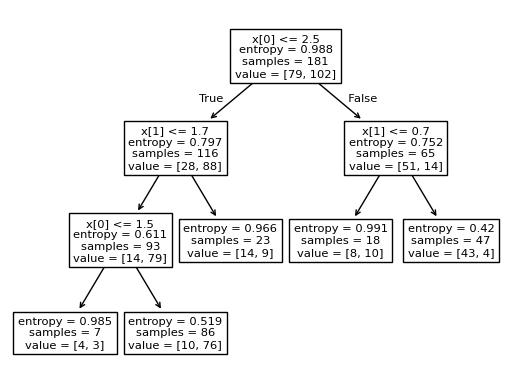

In [17]:
sklearn.tree.plot_tree(tree_model)
plt.show()

In [18]:
root_entropy = -(train_data["target"].value_counts() / len(train_data)) * np.log2(train_data["target"].value_counts() / len(train_data))
root_entropy.sum()

np.float64(0.9883206716849531)

Wir können sehen, dass die sklearn Implementierung des Entscheidungsbaums nicht gut mit kategorischen Variablen umgehen kann. Weder eine OneHot Enkodierung der Variablen noch die numerische Kodierung hier, ermöglichen korrektes Splitting wie in der Theorie besprochen. Dies ist in sklearn nur in der HistGradientBoosting Implementierung über den Parameter 'categorical_features' möglich. Die Empfehlung ist ansonsten die kategorische Features mit One-Hot-Encoding in verschiedene Features aufzuteilen.


Da der Baum auf nur zwei Features trainiert wurde, lassen sich die Entscheidungsregeln / Entscheidungsflächen auch sehr gut visualisieren

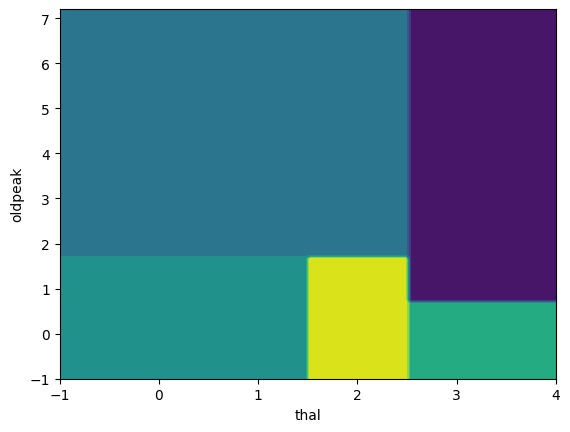

In [19]:
DecisionBoundaryDisplay.from_estimator(tree_model, X_train[["thal", "oldpeak"]])
plt.show()

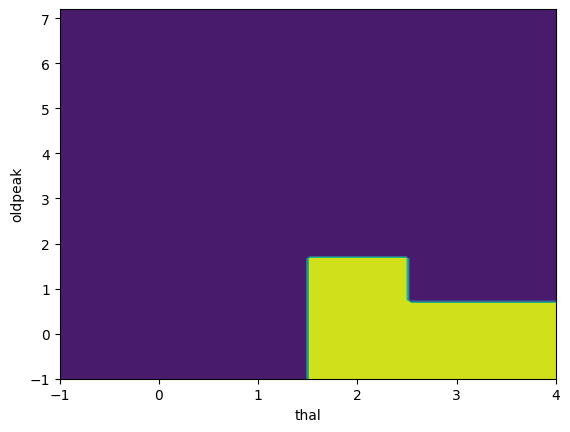

In [20]:
DecisionBoundaryDisplay.from_estimator(tree_model, X_train[["thal", "oldpeak"]], response_method="predict")
plt.show()

Komplexe Entscheidungsregeln:

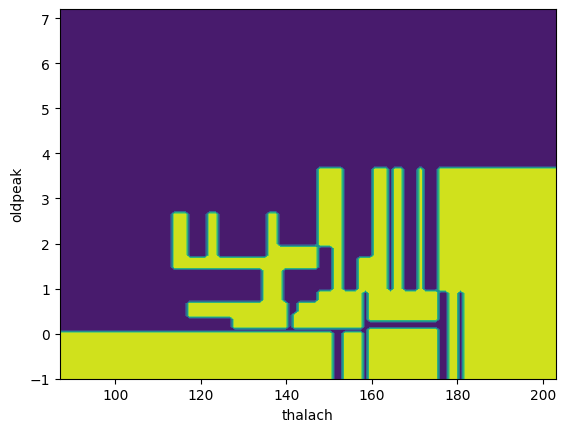

In [21]:
tree_model = DecisionTreeClassifier(criterion="entropy", max_depth=10)
tree_model.fit(X_train[["thalach", "oldpeak"]], y_train)
DecisionBoundaryDisplay.from_estimator(tree_model, X_train[["thalach", "oldpeak"]], response_method="predict")
plt.show()

### Ensemble Methoden

In [22]:
# Alternativen: BaggingClassifier, AdaBoostClassifier
param_grid = {
    "max_depth":(list(range(1, 20, 2))),
    "n_estimators":(list(range(50,501,50)))
}

all_combinations = list(ParameterGrid(param_grid))
training_results = {}
validation_results = {}

for i, params in enumerate(tqdm(all_combinations)):
    forest = RandomForestClassifier(**params, random_state=0)
    forest.fit(X_train, y_train)
    validation_results[i] = (forest.predict(X_val) == y_val).mean()

  0%|          | 0/100 [00:00<?, ?it/s]

In [23]:
params

{'max_depth': 19, 'n_estimators': 500}

In [24]:
all_combinations[max(validation_results.items(), key=lambda item : item[1])[0]]

{'max_depth': 9, 'n_estimators': 400}

In [25]:
pd.DataFrame(validation_results.items(), columns=["ID", "Val Accuracy"]).groupby("Val Accuracy").count()

,ID
Val Accuracy,
0.737705,1
0.770492,8
0.786885,15
0.803279,12
0.819672,32
0.836066,30
0.852459,2


In [26]:
forest = RandomForestClassifier(criterion="entropy", max_depth=2, max_features="sqrt", oob_score=True, random_state=0)
forest.fit(X_train, y_train)
print("Validation Accuracy der einzelnen Bäume:")
for tree in forest.estimators_[:5]:
    print(round(tree.score(X_val.to_numpy(), y_val), 2))
print("\nForest:", round(forest.score(X_val, y_val), 2))

Validation Accuracy der einzelnen Bäume:
0.7
0.64
0.7
0.7
0.69

Forest: 0.82


Bootstrapping, daher können wir uns auch den out-of-bag score anschauen ähnlich zu Validierungsdaten:

In [27]:
forest.oob_score_

0.8011049723756906

#### K-Fold Cross-Validation zum Hyperparameter Tuning

In [28]:
forest  = RandomForestClassifier(random_state=0)
gridsearch = GridSearchCV(forest, param_grid, scoring="accuracy", n_jobs=-1, verbose=1, cv=10, return_train_score=True)
gridsearch.fit(X_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [1, 3, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [29]:
gridsearch.best_params_

{'max_depth': 9, 'n_estimators': 300}

In [30]:
pd.DataFrame(gridsearch.cv_results_).iloc[[gridsearch.best_index_]].transpose()

,45
mean_fit_time,0.604577
std_fit_time,0.122361
mean_score_time,0.021695
std_score_time,0.00667
param_max_depth,9
param_n_estimators,300
params,"{'max_depth': 9, 'n_estimators': 300}"
split0_test_score,0.842105
split1_test_score,0.888889
split2_test_score,0.888889


In [31]:
pd.DataFrame(gridsearch.cv_results_)[["mean_train_score", "std_train_score", "mean_test_score", "std_test_score", "params"]]

,mean_train_score,std_train_score,mean_test_score,std_test_score,params
0,0.852670,0.013161,0.829240,0.089516,"{'max_depth': 1, 'n_estimators': 50}"
1,0.851450,0.009704,0.834503,0.073742,"{'max_depth': 1, 'n_estimators': 100}"
2,0.855741,0.009578,0.840058,0.071312,"{'max_depth': 1, 'n_estimators': 150}"
3,0.855131,0.010971,0.828947,0.062264,"{'max_depth': 1, 'n_estimators': 200}"
4,0.859426,0.010388,0.834503,0.069431,"{'max_depth': 1, 'n_estimators': 250}"
...,...,...,...,...,...
95,1.000000,0.000000,0.850877,0.086116,"{'max_depth': 19, 'n_estimators': 300}"
96,1.000000,0.000000,0.850877,0.086116,"{'max_depth': 19, 'n_estimators': 350}"
97,1.000000,0.000000,0.845322,0.085272,"{'max_depth': 19, 'n_estimators': 400}"
98,1.000000,0.000000,0.850877,0.086116,"{'max_depth': 19, 'n_estimators': 450}"


In [32]:
hist_boosting = sklearn.ensemble.HistGradientBoostingRegressor(random_state=0, max_depth=5, learning_rate=0.5, max_iter=1000, categorical_features=["cp", "restecg", "thal"])
hist_boosting.fit(X_train, y_train).score(X_val, y_val)

0.2668940908384959